In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import einops
import numpy as np
from dataclasses import dataclass
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# =============================================================================
# PART 1: The Toy Model (identical to ARENA)
# =============================================================================
# This is the "LLM" we're interpreting. It takes 5 features, compresses them
# to 2D (creating superposition), then tries to reconstruct them.
#
# The SAE/VAE will operate on the 2D hidden activations, trying to recover
# which of the 5 original features were active.

@dataclass
class ToyModelConfig:
    n_inst: int           # number of parallel models (to sweep sparsity)
    n_features: int = 5   # ground-truth features
    d_hidden: int = 2     # bottleneck dimensions (where superposition happens)


class ToyModel(nn.Module):
    """
    The toy "LLM" from Anthropic's superposition paper.

    Forward pass: x → h = Wx → x' = ReLU(W^T h + b)

    We only care about the hidden activations h = Wx.
    The SAE/VAE will try to decompose h back into the original features.
    """

    def __init__(self, cfg: ToyModelConfig, feature_probability=0.025, importance=1.0):
        super().__init__()
        self.cfg = cfg

        # --- Feature probability: how often each feature is "on" ---
        # Shape: (n_inst, n_features). Each instance can have different sparsity.
        if isinstance(feature_probability, float):
            feature_probability = torch.tensor(feature_probability)
        self.feature_probability = feature_probability.to(device).broadcast_to(
            (cfg.n_inst, cfg.n_features)
        )

        # --- Importance: how much we care about reconstructing each feature ---
        if isinstance(importance, float):
            importance = torch.tensor(importance)
        self.importance = importance.to(device).broadcast_to(
            (cfg.n_inst, cfg.n_features)
        )

        # --- Weights ---
        # W: shape (n_inst, d_hidden=2, n_features=5)
        # Think of it as n_inst separate 2×5 matrices.
        # Column i of W is where feature i lives in 2D space.
        self.W = nn.Parameter(
            nn.init.xavier_normal_(torch.empty((cfg.n_inst, cfg.d_hidden, cfg.n_features)))
        )
        self.b_final = nn.Parameter(torch.zeros((cfg.n_inst, cfg.n_features)))
        self.to(device)

    def generate_batch(self, batch_size: int):
        """
        Creates synthetic data: each feature is ON with probability feature_probability,
        and its value is uniform [0, 1] when on.

        Returns: shape (batch, n_inst, n_features)
        """
        # Random magnitudes uniform [0, 1]
        feat_mag = torch.rand(
            (batch_size, self.cfg.n_inst, self.cfg.n_features), device=device
        )
        # Random mask: each feature on with probability feature_probability
        feat_seed = torch.rand(
            (batch_size, self.cfg.n_inst, self.cfg.n_features), device=device
        )
        batch = torch.where(feat_seed <= self.feature_probability, feat_mag, 0.0)
        return batch

    def forward(self, features):
        """x → ReLU(W^T W x + b)"""
        # Encode: project features into 2D hidden space
        h = einops.einsum(
            features, self.W,
            "... inst feats, inst hidden feats -> ... inst hidden"
        )
        # Decode: project back to feature space
        out = einops.einsum(
            h, self.W,
            "... inst hidden, inst hidden feats -> ... inst feats"
        )
        return F.relu(out + self.b_final)

    def calculate_loss(self, out, batch):
        """Importance-weighted MSE"""
        error = self.importance * (out - batch).pow(2)
        return einops.reduce(error, "batch inst feats -> inst", "mean").sum()

    def optimize(self, batch_size=1024, steps=5000, lr=1e-3):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        for step in tqdm(range(steps), desc="Training toy model"):
            optimizer.zero_grad()
            batch = self.generate_batch(batch_size)
            out = self(batch)
            loss = self.calculate_loss(out, batch)
            loss.backward()
            optimizer.step()

    def get_hidden_activations(self, batch_size: int):
        """
        Generate data and return the 2D hidden activations h = Wx.
        This is what the SAE/VAE will train on.
        """
        with torch.no_grad():
            features = self.generate_batch(batch_size)
            h = einops.einsum(
                features, self.W,
                "batch inst feats, inst hidden feats -> batch inst hidden"
            )
        return h, features

In [ ]:
# =============================================================================
# PART 2: SAE (your MAP baseline)
# =============================================================================
# The SAE does: h → ReLU(W_enc @ h + b_enc) → z → W_dec @ z + b_dec → h'
# Loss = ||h - h'||² + λ||z||₁
#
# This is MAP inference: the L1 penalty is equivalent to a Laplace prior on z,
# and ReLU + point estimate = finding the mode of the posterior.

class ToySAE(nn.Module):
    def __init__(self, n_inst, d_in, d_sae, sparsity_coeff=0.2):
        super().__init__()
        self.n_inst = n_inst
        self.d_in = d_in          # = d_hidden of toy model = 2
        self.d_sae = d_sae        # = n_features = 5 (or more if overcomplete)
        self.sparsity_coeff = sparsity_coeff

        # Encoder: maps 2D hidden → d_sae latents
        self.W_enc = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_in, d_sae)))
        )
        # Decoder: maps d_sae latents → 2D reconstruction
        self.W_dec = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_sae, d_in)))
        )
        self.b_enc = nn.Parameter(torch.zeros(n_inst, d_sae))
        self.b_dec = nn.Parameter(torch.zeros(n_inst, d_in))
        self.to(device)

    @property
    def W_dec_normalized(self):
        """Normalize decoder columns so model can't cheat by scaling."""
        return self.W_dec / (self.W_dec.norm(dim=-1, keepdim=True) + 1e-8)

    def forward(self, h):
        """
        h: (batch, inst, d_in=2)
        Returns: reconstruction, latent activations, loss dict
        """
        h_cent = h - self.b_dec

        # Encode → sparse latent
        pre_acts = einops.einsum(
            h_cent, self.W_enc,
            "batch inst d_in, inst d_in d_sae -> batch inst d_sae"
        ) + self.b_enc
        z = F.relu(pre_acts)  # This is the "point estimate" — MAP inference

        # Decode
        h_recon = einops.einsum(
            z, self.W_dec_normalized,
            "batch inst d_sae, inst d_sae d_in -> batch inst d_in"
        ) + self.b_dec

        # Losses
        mse = (h_recon - h).pow(2).mean(dim=-1)       # (batch, inst)
        l1 = z.abs().sum(dim=-1)                        # (batch, inst)
        loss = mse + self.sparsity_coeff * l1

        return h_recon, z, {"mse": mse, "l1": l1, "loss": loss}

In [ ]:
# =============================================================================
# PART 3: Gaussian VAE (variational inference, NO sparsity)
# =============================================================================
# Instead of a point estimate, the encoder outputs a DISTRIBUTION q(z|h).
# We sample from it using the reparameterization trick.
#
# Prior: p(z) = N(0, I)  — standard Gaussian, no sparsity at all.
# Loss = reconstruction + β * KL(q(z|h) || p(z))
#
# This is your CONTROL: it isolates the effect of switching from MAP to VI,
# without changing the prior. Expected result: good reconstruction, zero sparsity.

class GaussianVAE(nn.Module):
    def __init__(self, n_inst, d_in, d_latent, beta=1.0):
        super().__init__()
        self.n_inst = n_inst
        self.d_in = d_in
        self.d_latent = d_latent
        self.beta = beta  # weight on KL term (β-VAE)

        # Encoder outputs TWO things: mean μ and log-variance log(σ²)
        self.W_enc_mu = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_in, d_latent)))
        )
        self.b_enc_mu = nn.Parameter(torch.zeros(n_inst, d_latent))

        self.W_enc_logvar = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_in, d_latent)))
        )
        self.b_enc_logvar = nn.Parameter(torch.zeros(n_inst, d_latent))

        # Decoder (same as SAE)
        self.W_dec = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_latent, d_in)))
        )
        self.b_dec = nn.Parameter(torch.zeros(n_inst, d_in))
        self.to(device)

    def encode(self, h):
        """h → (μ, log σ²)"""
        h_cent = h - self.b_dec
        mu = einops.einsum(
            h_cent, self.W_enc_mu,
            "batch inst d_in, inst d_in d_lat -> batch inst d_lat"
        ) + self.b_enc_mu
        logvar = einops.einsum(
            h_cent, self.W_enc_logvar,
            "batch inst d_in, inst d_in d_lat -> batch inst d_lat"
        ) + self.b_enc_logvar
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        The reparameterization trick:
        Instead of sampling z ~ N(μ, σ²) directly (which blocks gradients),
        we sample ε ~ N(0,1) and compute z = μ + σ * ε.
        This way gradients flow through μ and σ.
        """
        std = torch.exp(0.5 * logvar)     # σ = exp(log(σ²)/2)
        eps = torch.randn_like(std)        # ε ~ N(0, I)
        return mu + std * eps              # z = μ + σε

    def decode(self, z):
        """z → h_reconstructed"""
        return einops.einsum(
            z, self.W_dec,
            "batch inst d_lat, inst d_lat d_in -> batch inst d_in"
        ) + self.b_dec

    def forward(self, h):
        mu, logvar = self.encode(h)
        z = self.reparameterize(mu, logvar)
        h_recon = self.decode(z)

        # Reconstruction loss
        mse = (h_recon - h).pow(2).mean(dim=-1)  # (batch, inst)

        # KL divergence: KL(N(μ,σ²) || N(0,1)) has a closed-form solution
        # = -0.5 * Σ(1 + log(σ²) - μ² - σ²)
        kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=-1)

        loss = mse + self.beta * kl

        return h_recon, z, mu, logvar, {"mse": mse, "kl": kl, "loss": loss}

In [ ]:
# =============================================================================
# PART 3b: Laplace VAE (variational inference + Laplace/L1 prior)
# =============================================================================
# This is the CLEANEST comparison to the SAE.
#
# The SAE uses L1 regularization, which is equivalent to MAP under a Laplace prior.
# This VAE uses the SAME Laplace prior, but does variational inference instead.
#
# Prior: p(z_i) = Laplace(0, b) = (1/2b) * exp(-|z_i|/b)
# Posterior: q(z_i|h) = N(μ_i, σ_i²) — Gaussian for tractability
#
# KL(N(μ,σ²) || Laplace(0,b)) has no closed form, so we estimate it via
# Monte Carlo sampling. This is a bit noisier but avoids ALL the gate-collapse
# problems of the spike-and-slab.
#
# The parameter b controls sparsity: small b = strong sparsity (like high λ in SAE).
# Specifically, b = 1/λ, so they're inversely related.

class LaplaceVAE(nn.Module):
    def __init__(self, n_inst, d_in, d_latent, beta=1.0, laplace_b=0.5, n_mc_samples=5):
        """
        Args:
            laplace_b: scale of the Laplace prior. Smaller = more sparse.
                       b = 1/λ where λ is the SAE's L1 coefficient.
            n_mc_samples: number of Monte Carlo samples for KL estimation.
        """
        super().__init__()
        self.n_inst = n_inst
        self.d_in = d_in
        self.d_latent = d_latent
        self.beta = beta
        self.laplace_b = laplace_b
        self.n_mc_samples = n_mc_samples

        # Encoder outputs mean and log-variance (same as Gaussian VAE)
        self.W_enc_mu = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_in, d_latent)))
        )
        self.b_enc_mu = nn.Parameter(torch.zeros(n_inst, d_latent))

        self.W_enc_logvar = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_in, d_latent)))
        )
        self.b_enc_logvar = nn.Parameter(torch.full((n_inst, d_latent), -2.0))

        # Decoder
        self.W_dec = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_latent, d_in)))
        )
        self.b_dec = nn.Parameter(torch.zeros(n_inst, d_in))
        self.to(device)

    def encode(self, h):
        h_cent = h - self.b_dec
        mu = einops.einsum(
            h_cent, self.W_enc_mu,
            "batch inst d_in, inst d_in d_lat -> batch inst d_lat"
        ) + self.b_enc_mu
        logvar = einops.einsum(
            h_cent, self.W_enc_logvar,
            "batch inst d_in, inst d_in d_lat -> batch inst d_lat"
        ) + self.b_enc_logvar
        return mu, logvar.clamp(-10, 2)

    def decode(self, z):
        return einops.einsum(
            z, self.W_dec,
            "batch inst d_lat, inst d_lat d_in -> batch inst d_in"
        ) + self.b_dec

    def forward(self, h):
        mu, logvar = self.encode(h)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        h_recon = self.decode(z)

        # Reconstruction loss
        mse = (h_recon - h).pow(2).mean(dim=-1)

        # KL divergence estimated via Monte Carlo:
        # KL = E_q[log q(z|x) - log p(z)]
        # log q(z|x) for Gaussian = -0.5 * (log(2π) + logvar + (z-μ)²/σ²)
        # log p(z) for Laplace = -log(2b) - |z|/b
        #
        # The Gaussian entropy term is: 0.5 * (1 + log(2π) + logvar) per dim
        # The cross-entropy with Laplace: E_q[-log p(z)] = log(2b) + E_q[|z|]/b
        # So: KL = -0.5*(1 + logvar) + log(2b) + E_q[|z|]/b
        #     (the log(2π) cancels out)
        #
        # E_q[|z|] for z ~ N(μ,σ²) has a known formula:
        #   E[|z|] = σ√(2/π)·exp(-μ²/(2σ²)) + μ·(1 - 2Φ(-μ/σ))
        # where Φ is the standard normal CDF.

        b = self.laplace_b
        sigma = std

        # E[|z|] where z ~ N(mu, sigma^2)
        mu_over_sigma = mu / (sigma + 1e-8)
        expected_abs_z = (
            sigma * (2.0 / np.pi) ** 0.5 * torch.exp(-0.5 * mu_over_sigma ** 2)
            + mu * (1.0 - 2.0 * torch.distributions.Normal(0, 1).cdf(-mu_over_sigma))
        )

        # KL per latent dimension
        kl_per_dim = -0.5 * (1 + logvar) + np.log(2 * b) + expected_abs_z / b
        kl = kl_per_dim.sum(dim=-1)  # sum over latents → (batch, inst)

        loss = mse + self.beta * kl

        # For the evaluate function, z needs to be "sparse" — use ReLU to match SAE convention
        # (This doesn't affect training, just evaluation of L0)
        return h_recon, z, mu, logvar, {"mse": mse, "kl": kl, "loss": loss}


# =============================================================================
# PART 4: Sparse VAE (variational inference + spike-and-slab prior)
# =============================================================================
# THIS IS THE MAIN EVENT for your project.
#
# Prior: p(z_i) = (1-π)δ₀ + π·N(0,1)
#   → each latent is either OFF (with prob 1-π) or drawn from a Gaussian (prob π)
#   → this encodes "most concepts are off" — exactly the SAE's assumption
#
# The encoder outputs three things per latent:
#   - gate logit (is this feature on or off?)
#   - μ (if on, what's the mean?)
#   - log σ² (if on, what's the uncertainty?)
#
# We use Gumbel-Softmax / Concrete relaxation for the gate so gradients flow.
# The effective latent is: z_i = gate_i * sample_from_N(μ_i, σ²_i)

class SpikeSlabVAE(nn.Module):
    def __init__(self, n_inst, d_in, d_latent, beta=1.0, prior_pi=0.1, temperature=0.5,
                 free_bits=0.1):
        """
        Args:
            prior_pi: prior probability that a feature is ON.
                      Small = sparse (like high λ in SAE).
                      0.1 means "we expect ~10% of features active"
            temperature: Gumbel-softmax temperature.
                         Lower = harder gates (more like 0/1).
                         Higher = softer gates (more gradient flow but less sparse).
            free_bits: minimum KL per latent before it's penalized.
                       This prevents posterior collapse by giving each latent
                       a "budget" of KL it can use for free. Without this,
                       the model finds it cheaper to turn all gates off and
                       just use b_dec to memorize the data mean.
        """
        super().__init__()
        self.n_inst = n_inst
        self.d_in = d_in
        self.d_latent = d_latent
        self.beta = beta
        self.prior_pi = prior_pi
        self.temperature = temperature
        self.free_bits = free_bits

        # Encoder: produces gate logits, mean, and log-variance
        self.W_enc_gate = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_in, d_latent)))
        )
        # FIX 1: Initialize gate biases POSITIVE so gates start ON.
        # If we start at 0, sigmoid(0)=0.5, and the KL pushes gates toward
        # the prior (which is small, like 0.1), so they collapse to OFF before
        # the encoder learns anything useful. Starting at +2 means sigmoid(2)≈0.88,
        # so gates start mostly ON → encoder learns to use the latents for
        # reconstruction → THEN the KL gradually makes the unneeded ones turn off.
        self.b_enc_gate = nn.Parameter(torch.full((n_inst, d_latent), 2.0))

        self.W_enc_mu = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_in, d_latent)))
        )
        self.b_enc_mu = nn.Parameter(torch.zeros(n_inst, d_latent))

        self.W_enc_logvar = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_in, d_latent)))
        )
        # FIX 2: Initialize logvar to small negative value (small variance)
        # so the continuous part starts precise, not diffuse
        self.b_enc_logvar = nn.Parameter(torch.full((n_inst, d_latent), -2.0))

        # Decoder
        self.W_dec = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty((n_inst, d_latent, d_in)))
        )
        self.b_dec = nn.Parameter(torch.zeros(n_inst, d_in))
        self.to(device)

    def encode(self, h):
        h_cent = h - self.b_dec

        gate_logits = einops.einsum(
            h_cent, self.W_enc_gate,
            "batch inst d_in, inst d_in d_lat -> batch inst d_lat"
        ) + self.b_enc_gate

        mu = einops.einsum(
            h_cent, self.W_enc_mu,
            "batch inst d_in, inst d_in d_lat -> batch inst d_lat"
        ) + self.b_enc_mu

        logvar = einops.einsum(
            h_cent, self.W_enc_logvar,
            "batch inst d_in, inst d_in d_lat -> batch inst d_lat"
        ) + self.b_enc_logvar

        return gate_logits, mu, logvar

    def sample_gate(self, gate_logits):
        """
        Concrete / Gumbel-Softmax relaxation of Bernoulli.

        The gate should be 0 or 1, but that's not differentiable.
        Gumbel-softmax gives a continuous approximation:
        - During training: soft values between 0 and 1
        - The temperature controls how close to 0/1 they are
        """
        if self.training:
            # Gumbel noise for the "on" and "off" logits
            uniform = torch.rand_like(gate_logits).clamp(1e-6, 1 - 1e-6)
            gumbel_noise = -torch.log(-torch.log(uniform))

            uniform2 = torch.rand_like(gate_logits).clamp(1e-6, 1 - 1e-6)
            gumbel_noise2 = -torch.log(-torch.log(uniform2))

            # Soft gate via sigmoid (binary Concrete distribution)
            gate = torch.sigmoid(
                (gate_logits + gumbel_noise - gumbel_noise2) / self.temperature
            )
        else:
            # At eval time: hard threshold
            gate = (gate_logits > 0).float()
        return gate

    def decode(self, z):
        return einops.einsum(
            z, self.W_dec,
            "batch inst d_lat, inst d_lat d_in -> batch inst d_in"
        ) + self.b_dec

    def forward(self, h):
        gate_logits, mu, logvar = self.encode(h)

        # Clamp logvar for numerical stability
        logvar = logvar.clamp(-10, 2)

        # Sample the gate (on/off per feature)
        gate = self.sample_gate(gate_logits)

        # Sample the continuous part (reparameterization trick)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z_continuous = mu + std * eps

        # Final latent = gate * continuous
        # If gate ≈ 0, the feature is OFF. If gate ≈ 1, feature is ON with value z_continuous.
        z = gate * z_continuous

        # Reconstruct
        h_recon = self.decode(z)

        # === Loss computation ===

        # 1. Reconstruction loss
        mse = (h_recon - h).pow(2).mean(dim=-1)  # (batch, inst)

        # 2. KL divergence for the spike-and-slab prior
        # This has two parts:
        #
        # (a) KL for the gate (Bernoulli q(s|h) vs Bernoulli(π))
        q_pi = torch.sigmoid(gate_logits)  # posterior probability of being ON
        q_pi = q_pi.clamp(1e-6, 1 - 1e-6)
        prior_pi = torch.tensor(self.prior_pi, device=h.device)

        kl_gate_per_latent = (
            q_pi * (torch.log(q_pi) - torch.log(prior_pi))
            + (1 - q_pi) * (torch.log(1 - q_pi) - torch.log(1 - prior_pi))
        )  # (batch, inst, d_latent)

        # (b) KL for the continuous part (only matters when gate is on)
        #     KL(N(μ,σ²) || N(0,1)) weighted by the gate probability
        kl_continuous_per_latent = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
        kl_continuous_per_latent = q_pi * kl_continuous_per_latent  # (batch, inst, d_latent)

        # FIX 3: Free bits — don't penalize KL below a threshold PER LATENT.
        # Without this, the cheapest solution is "turn everything off, pay zero KL."
        # Free bits says: each latent gets free_bits nats of KL for free.
        # Only the excess above that threshold contributes to loss.
        # This guarantees the model actually USES the latents.
        kl_per_latent = kl_gate_per_latent + kl_continuous_per_latent
        kl_per_latent = torch.clamp(kl_per_latent - self.free_bits, min=0.0)

        kl = kl_per_latent.sum(dim=-1)  # (batch, inst)
        kl_gate = kl_gate_per_latent.sum(dim=-1)  # for logging
        loss = mse + self.beta * kl

        return h_recon, z, gate, mu, logvar, {"mse": mse, "kl": kl, "kl_gate": kl_gate, "loss": loss}

In [ ]:
# =============================================================================
# PART 5: Training helpers
# =============================================================================

def train_sae(model, sae, steps=5000, batch_size=1024, lr=1e-3):
    """Train an SAE on the toy model's hidden activations."""
    optimizer = torch.optim.Adam(sae.parameters(), lr=lr)
    losses = []
    for step in tqdm(range(steps), desc=f"SAE (λ={sae.sparsity_coeff:.3f})"):
        optimizer.zero_grad()
        h, _ = model.get_hidden_activations(batch_size)
        h_recon, z, loss_dict = sae(h)
        loss = loss_dict["loss"].mean()
        loss.backward()
        optimizer.step()
        if step % 100 == 0:
            losses.append(loss.item())
    return losses


def train_vae(model, vae, steps=5000, batch_size=1024, lr=1e-3, kl_warmup=1000):
    """
    Train a VAE (Gaussian or Sparse) on the toy model's hidden activations.

    kl_warmup: number of steps over which to linearly increase the KL weight.
    This prevents "posterior collapse" — where the VAE ignores z and just
    memorizes via the decoder. By starting with β≈0, the encoder learns to
    use z for reconstruction first, then the KL gradually pushes it to match
    the prior.
    """
    optimizer = torch.optim.Adam(vae.parameters(), lr=lr)
    original_beta = vae.beta
    losses = []

    for step in tqdm(range(steps), desc=f"VAE (β={original_beta:.2f})"):
        # KL annealing: linearly increase β from 0 to original_beta
        if step < kl_warmup:
            vae.beta = original_beta * (step / kl_warmup)
        else:
            vae.beta = original_beta

        optimizer.zero_grad()
        h, _ = model.get_hidden_activations(batch_size)

        # Both VAE types return loss_dict as the last element
        results = vae(h)
        loss_dict = results[-1]
        loss = loss_dict["loss"].mean()
        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            losses.append(loss.item())

    vae.beta = original_beta
    return losses

In [ ]:
# =============================================================================
# PART 6: Evaluation
# =============================================================================

@torch.no_grad()
def evaluate(model, method, n_eval=10000):
    """
    Compute reconstruction MSE and L0 sparsity for any method.

    L0 = average number of "active" features per input.
    The threshold is adaptive: 1% of each method's max activation magnitude.
    This is fair because the SAE produces large activations (ReLU, no KL constraint)
    while the VAE produces small activations (KL pushes toward zero).
    """
    h, features = model.get_hidden_activations(n_eval)
    method.eval()

    results = method(h)
    h_recon = results[0]

    mse = (h_recon - h).pow(2).mean(dim=-1).mean(dim=0)  # (n_inst,)

    # Get the right activation tensor depending on model type
    if isinstance(method, ToySAE):
        acts = results[1]  # z after ReLU
    elif isinstance(method, SpikeSlabVAE):
        # Use gate * |z| — if gate is off, feature is off
        gate = results[2]
        z = results[1]
        acts = gate * z.abs()
    else:
        # Gaussian or Laplace VAE: use posterior mean
        acts = results[2]  # mu

    # Adaptive threshold: 1% of max activation per instance
    # This handles the scale difference between SAE and VAE
    max_act = acts.abs().reshape(-1, acts.shape[-1]).max(dim=0)[0]  # per latent
    threshold = 0.01 * max_act.max().clamp(min=1e-6)

    l0 = (acts.abs() > threshold).float().sum(dim=-1).mean(dim=0)  # (n_inst,)

    method.train()
    return mse.cpu().numpy(), l0.cpu().numpy()

Step 1: Training the toy model (the 'LLM')


Training toy model:   0%|          | 0/5000 [00:00<?, ?it/s]


Step 2: Training SAEs (MAP baseline)


SAE (λ=0.010):   0%|          | 0/5000 [00:00<?, ?it/s]

  λ=0.010 → MSE=0.0000, L0=0.24


...

  π=0.10, β=0.05 → MSE=0.0275, L0=0.00


VAE (β=0.10):   0%|          | 0/8000 [00:00<?, ?it/s]

  π=0.10, β=0.10 → MSE=0.0280, L0=0.00


VAE (β=0.50):   0%|          | 0/8000 [00:00<?, ?it/s]

  π=0.10, β=0.50 → MSE=0.0275, L0=0.00

Step 6: Plotting Pareto curves


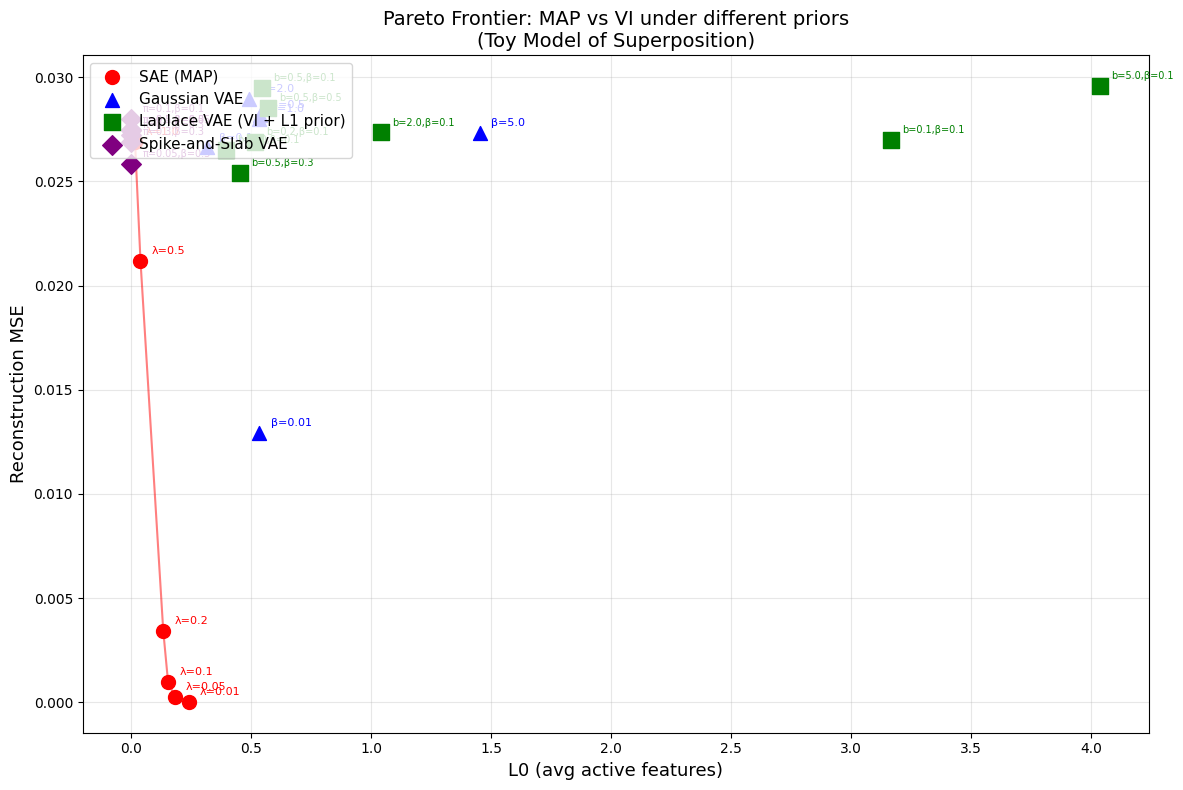


Saved to pareto_comparison.png

Bonus: Posterior uncertainty from Laplace VAE


VAE (β=0.10):   0%|          | 0/5000 [00:00<?, ?it/s]


For instance 0, averaged over 1000 samples:
  Mean posterior μ:           [-0.  0.  0. -0.  0.]
  Mean posterior σ:           [0.627 0.627 0.627 0.627 0.627]
  Mean |z|:                   [0.508 0.481 0.484 0.495 0.509]

  → The SAE gives you NONE of this uncertainty info.
  → High σ = model unsure if concept is present = Experiment 3.1!


In [ ]:
# =============================================================================
# PART 7: Run everything and plot Pareto curves
# =============================================================================

if __name__ == "__main__":

    # --- Step 1: Train the toy model ---
    print("=" * 60)
    print("Step 1: Training the toy model (the 'LLM')")
    print("=" * 60)

    n_inst = 8   # we'll use instance 0 for everything (they're all the same here)
    n_features = 5
    d_hidden = 2

    cfg = ToyModelConfig(n_inst=n_inst, n_features=n_features, d_hidden=d_hidden)
    model = ToyModel(cfg, feature_probability=0.025)
    model.optimize(steps=5000)

    # Make all instances identical (we want the same base model for fair comparison)
    model.W.data[1:] = model.W.data[0]
    model.b_final.data[1:] = model.b_final.data[0]

    # --- Step 2: Train SAEs at different sparsity levels ---
    print("\n" + "=" * 60)
    print("Step 2: Training SAEs (MAP baseline)")
    print("=" * 60)

    sae_lambdas = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
    sae_results = []

    for lam in sae_lambdas:
        sae = ToySAE(n_inst=n_inst, d_in=d_hidden, d_sae=n_features, sparsity_coeff=lam)
        train_sae(model, sae, steps=5000)
        mse, l0 = evaluate(model, sae)
        sae_results.append({"lambda": lam, "mse": mse[0], "l0": l0[0]})
        print(f"  λ={lam:.3f} → MSE={mse[0]:.4f}, L0={l0[0]:.2f}")

    # --- Step 3: Train Gaussian VAEs (control — no sparsity) ---
    print("\n" + "=" * 60)
    print("Step 3: Training Gaussian VAEs (VI, no sparsity)")
    print("=" * 60)

    gauss_betas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
    gauss_results = []

    for beta in gauss_betas:
        vae = GaussianVAE(n_inst=n_inst, d_in=d_hidden, d_latent=n_features, beta=beta)
        train_vae(model, vae, steps=5000, kl_warmup=1000)
        mse, l0 = evaluate(model, vae)
        gauss_results.append({"beta": beta, "mse": mse[0], "l0": l0[0]})
        print(f"  β={beta:.2f} → MSE={mse[0]:.4f}, L0={l0[0]:.2f}")

    # --- Step 4: Train Laplace VAEs (VI + L1 prior — direct SAE comparison) ---
    print("\n" + "=" * 60)
    print("Step 4: Training Laplace VAEs (VI + Laplace prior)")
    print("=" * 60)

    # laplace_b = 1/lambda, so small b = strong sparsity
    laplace_configs = [
        {"laplace_b": 5.0,  "beta": 0.1},   # very weak sparsity
        {"laplace_b": 2.0,  "beta": 0.1},
        {"laplace_b": 1.0,  "beta": 0.1},
        {"laplace_b": 0.5,  "beta": 0.1},
        {"laplace_b": 0.2,  "beta": 0.1},
        {"laplace_b": 0.1,  "beta": 0.1},   # strong sparsity (like λ=10)
        {"laplace_b": 0.5,  "beta": 0.3},
        {"laplace_b": 0.5,  "beta": 0.5},
    ]
    laplace_results = []

    for lc in laplace_configs:
        vae = LaplaceVAE(
            n_inst=n_inst, d_in=d_hidden, d_latent=n_features,
            beta=lc["beta"], laplace_b=lc["laplace_b"]
        )
        train_vae(model, vae, steps=5000, kl_warmup=1500)
        mse, l0 = evaluate(model, vae)
        laplace_results.append({**lc, "mse": mse[0], "l0": l0[0]})
        print(f"  b={lc['laplace_b']:.1f}, β={lc['beta']:.2f} → MSE={mse[0]:.4f}, L0={l0[0]:.2f}")

    # --- Step 5: Train Spike-and-Slab VAEs ---
    print("\n" + "=" * 60)
    print("Step 5: Training Spike-and-Slab VAEs")
    print("=" * 60)

    sparse_configs = [
        # Sweep prior_pi (sparsity) — free_bits=0.5 prevents gate collapse
        {"prior_pi": 0.5,  "beta": 0.3, "free_bits": 0.5},
        {"prior_pi": 0.3,  "beta": 0.3, "free_bits": 0.5},
        {"prior_pi": 0.1,  "beta": 0.3, "free_bits": 0.5},
        {"prior_pi": 0.05, "beta": 0.3, "free_bits": 0.5},
        # Sweep beta at fixed prior_pi
        {"prior_pi": 0.1,  "beta": 0.05, "free_bits": 0.5},
        {"prior_pi": 0.1,  "beta": 0.1,  "free_bits": 0.5},
        {"prior_pi": 0.1,  "beta": 0.5,  "free_bits": 0.5},
    ]
    sparse_results = []

    for sc in sparse_configs:
        vae = SpikeSlabVAE(
            n_inst=n_inst, d_in=d_hidden, d_latent=n_features,
            beta=sc["beta"], prior_pi=sc["prior_pi"], temperature=0.5,
            free_bits=sc["free_bits"]
        )
        # Longer training + longer warmup for spike-and-slab
        train_vae(model, vae, steps=8000, kl_warmup=3000)
        mse, l0 = evaluate(model, vae)
        sparse_results.append({**sc, "mse": mse[0], "l0": l0[0]})
        print(f"  π={sc['prior_pi']:.2f}, β={sc['beta']:.2f} → MSE={mse[0]:.4f}, L0={l0[0]:.2f}")



    # --- Bonus: show posterior uncertainty from Laplace VAE ---
    print("\n" + "=" * 60)
    print("Bonus: Posterior uncertainty from Laplace VAE")
    print("=" * 60)

    # Train one Laplace VAE and inspect its uncertainty
    vae = LaplaceVAE(
        n_inst=n_inst, d_in=d_hidden, d_latent=n_features,
        beta=0.1, laplace_b=0.5
    )
    train_vae(model, vae, steps=5000, kl_warmup=1500)

    with torch.no_grad():
        h, features = model.get_hidden_activations(1000)
        vae.eval()
        h_recon, z, mu, logvar, loss_dict = vae(h)

        std = torch.exp(0.5 * logvar)

        # Show for instance 0
        print("\nFor instance 0, averaged over 1000 samples:")
        print(f"  Mean posterior μ:           {mu[:, 0, :].mean(0).cpu().numpy().round(3)}")
        print(f"  Mean posterior σ:           {std[:, 0, :].mean(0).cpu().numpy().round(3)}")
        print(f"  Mean |z|:                   {z[:, 0, :].abs().mean(0).cpu().numpy().round(3)}")
        print("\n  → The SAE gives you NONE of this uncertainty info.")
        print("  → High σ = model unsure if concept is present = Experiment 3.1!")


Step 6: Plotting Pareto curves


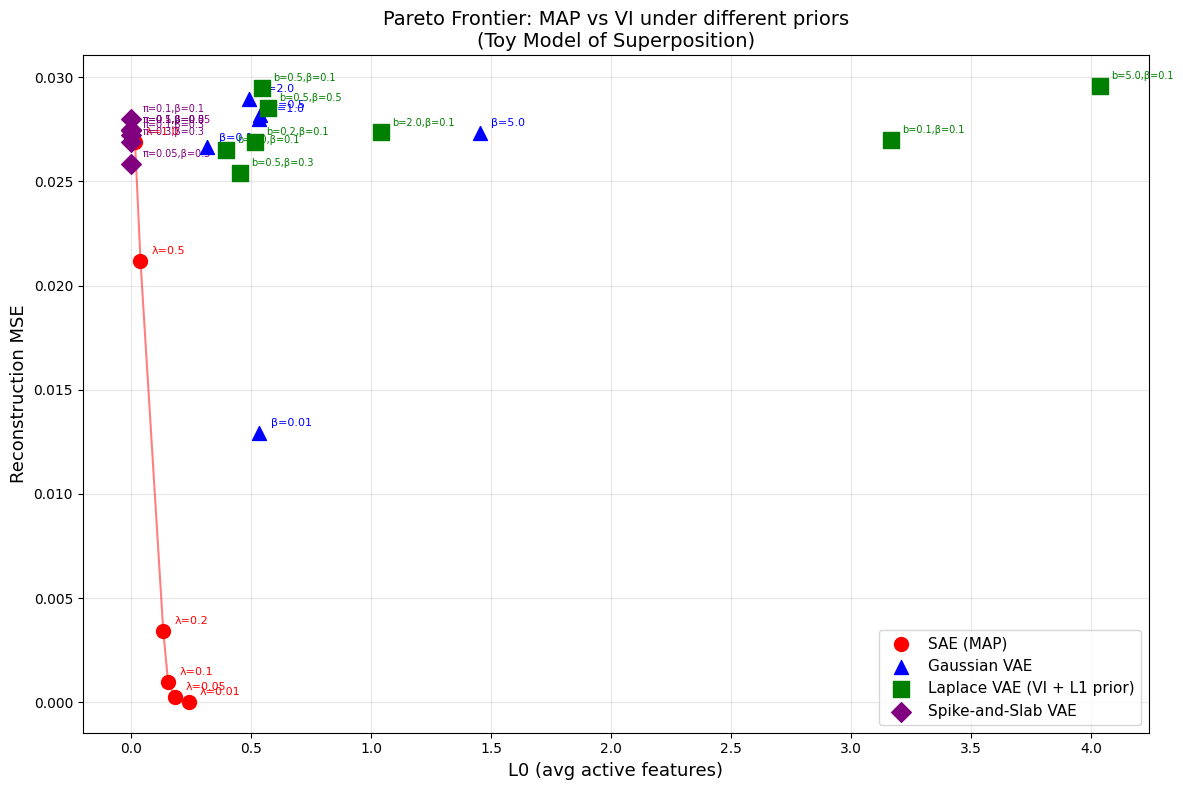


Saved to pareto_comparison.png


In [ ]:
# --- Step 6: Plot the Pareto frontier ---
print("\n" + "=" * 60)
print("Step 6: Plotting Pareto curves")
print("=" * 60)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# SAE points
sae_mses = [r["mse"] for r in sae_results]
sae_l0s = [r["l0"] for r in sae_results]
ax.scatter(sae_l0s, sae_mses, c="red", s=100, zorder=5, label="SAE (MAP)")
ax.plot(sae_l0s, sae_mses, c="red", alpha=0.5)
for r in sae_results:
    ax.annotate(f'λ={r["lambda"]}', (r["l0"], r["mse"]),
                  textcoords="offset points", xytext=(8, 5), fontsize=8, color="red")

# Gaussian VAE points
gauss_mses = [r["mse"] for r in gauss_results]
gauss_l0s = [r["l0"] for r in gauss_results]
ax.scatter(gauss_l0s, gauss_mses, c="blue", s=100, zorder=5, marker="^", label="Gaussian VAE")
for r in gauss_results:
    ax.annotate(f'β={r["beta"]}', (r["l0"], r["mse"]),
                  textcoords="offset points", xytext=(8, 5), fontsize=8, color="blue")

# Laplace VAE points
lap_mses = [r["mse"] for r in laplace_results]
lap_l0s = [r["l0"] for r in laplace_results]
ax.scatter(lap_l0s, lap_mses, c="green", s=120, zorder=5, marker="s",
            label="Laplace VAE (VI + L1 prior)")
for r in laplace_results:
    ax.annotate(f'b={r["laplace_b"]},β={r["beta"]}', (r["l0"], r["mse"]),
                  textcoords="offset points", xytext=(8, 5), fontsize=7, color="green")

# Spike-and-Slab VAE points
sparse_mses = [r["mse"] for r in sparse_results]
sparse_l0s = [r["l0"] for r in sparse_results]
ax.scatter(sparse_l0s, sparse_mses, c="purple", s=100, zorder=5, marker="D",
            label="Spike-and-Slab VAE")
for r in sparse_results:
    ax.annotate(f'π={r["prior_pi"]},β={r["beta"]}', (r["l0"], r["mse"]),
                  textcoords="offset points", xytext=(8, 5), fontsize=7, color="purple")

ax.set_xlabel("L0 (avg active features)", fontsize=13)
ax.set_ylabel("Reconstruction MSE", fontsize=13)
ax.set_title("Pareto Frontier: MAP vs VI under different priors\n(Toy Model of Superposition)", fontsize=14)
ax.legend(fontsize=11, loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pareto_comparison.png", dpi=150)
plt.show()
print("\nSaved to pareto_comparison.png")

## PART 8: Feature directions in 2D (ARENA-style), for SAE *and* VAEs

The toy model's hidden space is 2D, so every "feature direction" is just a 2D
vector we can draw as an arrow -- exactly like Anthropic's superposition plots.

Each model's decoder `W_dec` has shape `(n_inst, d_latent, 2)`, so **latent `j`'s
decoder row lives in the same 2D plane** the toy model packs its 5 features into.
We overlay:

- **grey dashed** arrows = the toy model's ground-truth feature directions,
- **coloured** arrows = the directions each SAE / VAE latent learned.

The VAE plots add what the SAE point-estimate cannot: arrow **opacity is proportional
to confidence**. For the Gaussian / Laplace VAEs confidence = `1/(1+mean posterior sigma)`;
for the spike-and-slab VAE it's the mean gate probability (how often that latent is
"on"). A faint arrow = a latent the model is unsure about. (This is the visual hook
for Experiments 3.1 / 3.2 in the roadmap.)

In [ ]:
# =============================================================================
# PART 8: Visualizing learned feature directions in 2D (ARENA-style)
# =============================================================================
# Because the toy hidden space is 2D, each latent's decoder column W_dec[inst, j]
# is a 2D arrow. We draw the toy model's ground-truth feature dirs (grey dashed)
# and each model's learned decoder dirs on top. For VAEs we shade arrows by a
# per-latent "confidence" the SAE has no analogue for.

@torch.no_grad()
def _decoder_dirs(module, inst=0):
    """Unit-normalized decoder directions, shape (d_latent, 2). We normalize so
    the plot compares *angles* (the superposition geometry); VAE decoders aren't
    norm-constrained, so raw lengths aren't comparable across models."""
    W = module.W_dec_normalized if hasattr(module, "W_dec_normalized") else module.W_dec
    d = W[inst].detach().float().cpu()
    return d / (d.norm(dim=-1, keepdim=True) + 1e-8)


@torch.no_grad()
def _latent_confidence(module, h, inst=0):
    """Per-latent confidence in (0, 1], or None for a model with no encoder (SAE).
      - Gaussian / Laplace VAE  (encode -> mu, logvar):    1 / (1 + mean posterior std)
      - Spike-slab VAE          (encode -> logits, mu, lv): mean gate "on" probability
    """
    if not hasattr(module, "encode"):
        return None
    module.eval()
    out = module.encode(h)
    if len(out) == 3:                                   # spike-and-slab
        return torch.sigmoid(out[0])[:, inst].mean(0).cpu()
    logvar = out[-1]                                    # gaussian / laplace
    std = torch.exp(0.5 * logvar)[:, inst].mean(0).cpu()
    return 1.0 / (1.0 + std)


def plot_features_in_2d(modules, titles, toy_model=None, h_eval=None, inst=0):
    """Draw decoder feature directions for one or more SAE/VAE modules as 2D arrows.

    modules   : list of trained SAE/VAE modules (each with .W_dec of shape (n_inst, d_latent, 2))
    titles    : subplot titles
    toy_model : optional ToyModel; its ground-truth feature dirs are drawn faintly
    h_eval    : optional (batch, n_inst, 2) activations; if given, VAE arrows are
                shaded by per-latent confidence (see _latent_confidence)
    """
    n = len(modules)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.4), squeeze=False)
    axes = axes[0]

    truth = None
    if toy_model is not None:
        # toy W is (n_inst, d_hidden=2, n_features); columns are feature dirs
        W = toy_model.W[inst].detach().float().cpu()            # (2, n_features)
        truth = (W / (W.norm(dim=0, keepdim=True) + 1e-8)).T    # (n_features, 2)

    for ax, mod, title in zip(axes, modules, titles):
        dirs = _decoder_dirs(mod, inst)                                  # (d_latent, 2)
        conf = _latent_confidence(mod, h_eval, inst) if h_eval is not None else None

        if truth is not None:
            for f in range(truth.shape[0]):
                ax.plot([0, truth[f, 0]], [0, truth[f, 1]],
                        color="0.75", lw=1.5, ls="--", zorder=1)

        for j in range(dirs.shape[0]):
            x, y = float(dirs[j, 0]), float(dirs[j, 1])
            if conf is not None:
                c = float(conf[j])
                rng = float(conf.max() - conf.min()) + 1e-8
                a = (c - float(conf.min())) / rng          # 0..1 within this model
                alpha = float(0.2 + 0.8 * a)
                lw = 1.0 + 3.0 * a
            else:
                alpha, lw = 0.9, 2.6
            ax.annotate("", xy=(x, y), xytext=(0, 0),
                        arrowprops=dict(arrowstyle="-|>", color="C0", alpha=alpha, lw=lw),
                        zorder=3)

        ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25); ax.set_aspect("equal")
        ax.axhline(0, color="0.92", lw=0.8); ax.axvline(0, color="0.92", lw=0.8)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=11)

    sub = ("grey dashed = ground-truth features"
           + ("   |   VAE arrow opacity/width is proportional to per-latent confidence"
              if h_eval is not None else ""))
    fig.suptitle("Decoder feature directions in the 2D hidden space\n" + sub, fontsize=10)
    plt.tight_layout(); plt.show()


# --- Demo: train one of each on the same toy model, then plot side by side -----
if __name__ == "__main__":
    torch.manual_seed(0)
    cfg = ToyModelConfig(n_inst=4, n_features=5, d_hidden=2)
    toy = ToyModel(cfg, feature_probability=0.025)
    toy.optimize(steps=5000)
    toy.W.data[1:] = toy.W.data[0]
    toy.b_final.data[1:] = toy.b_final.data[0]

    sae   = ToySAE(cfg.n_inst, d_in=2, d_sae=5, sparsity_coeff=0.05)
    gauss = GaussianVAE(cfg.n_inst, d_in=2, d_latent=5, beta=0.3)
    lap   = LaplaceVAE(cfg.n_inst, d_in=2, d_latent=5, beta=1.0, laplace_b=0.3)
    spike = SpikeSlabVAE(cfg.n_inst, d_in=2, d_latent=5, beta=1.0, prior_pi=0.1)

    train_sae(toy, sae)
    for v in (gauss, lap, spike):
        train_vae(toy, v)

    h_eval, _ = toy.get_hidden_activations(4096)
    plot_features_in_2d(
        [sae, gauss, lap, spike],
        ["SAE (MAP)", "Gaussian VAE", "Laplace VAE", "Spike-Slab VAE"],
        toy_model=toy, h_eval=h_eval,
    )
